# Nome: Sandro Campos Nogueira
# Matrícula: 2260644

## Import all packages need in the cell below

In [5]:
import Pkg
Pkg.add(["LinearAlgebra", "ForwardDiff", "JuMP", "Ipopt", "Plots", "Optim", "NLsolve"])

    Updating registry at `C:\Users\kmcva\.julia\registries\General.toml`
   Resolving package versions...
   Installed ADTypes ────────────────── v1.21.0
   Installed PositiveFactorizations ─── v0.2.4
   Installed ConstructionBase ───────── v1.6.0
   Installed EnumX ──────────────────── v1.0.7
   Installed NLsolve ────────────────── v4.5.1
   Installed NLSolversBase ──────────── v7.10.0
   Installed FiniteDiff ─────────────── v2.30.0
   Installed Distances ──────────────── v0.10.12
   Installed Setfield ───────────────── v1.1.2
   Installed LineSearches ───────────── v7.5.1
   Installed ArrayInterface ─────────── v7.24.0
   Installed FillArrays ─────────────── v1.16.0
   Installed DifferentiationInterface ─ v0.7.16
   Installed Optim ──────────────────── v1.13.3
   Installed Adapt ──────────────────── v4.5.2
    Updating `C:\Users\kmcva\.julia\environments\v1.12\Project.toml`
  [f6369f11] + ForwardDiff v1.3.3
  [2774e3e8] + NLsolve v4.5.1
⌃ [429524aa] + Optim v1.13.3
  [37e2e46d] + Lin

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

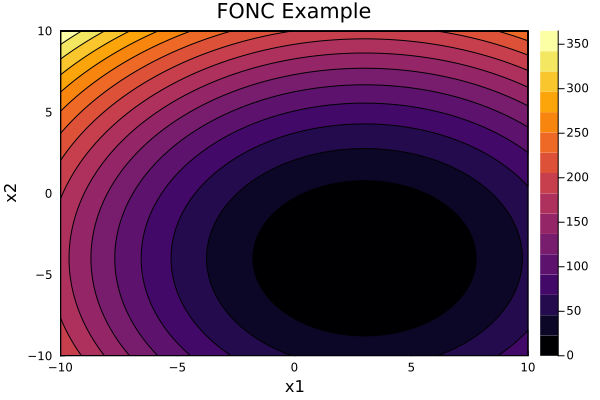

In [7]:
using Plots

f_fonc(x) = (x[1]-3)^2 + (x[2]+4)^2
x1_range = -10:0.1:10
x2_range = -10:0.1:10

# Agora o contour vai funcionar
contour(x1_range, x2_range, (x1, x2) -> f_fonc([x1, x2]), 
        fill=true, 
        title="FONC Example",
        xlabel="x1", 
        ylabel="x2")

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [9]:
using Optim    # Necessário para a função optimize
using NLsolve  # Necessário para a função nlsolve

# Definição da função
z_func(x) = (x[1]-1)^4 + (x[2]-2)^4

# 1. Usando Optim.jl para encontrar o mínimo direto
res_optim = optimize(z_func, [0.0, 0.0])
println("Mínimo pelo Optim: ", res_optim.minimizer)

# 2. Usando NLsolve para resolver a FONC (onde o gradiente é zero)
# O gradiente de z é [4(x1-1)³, 4(x2-2)³]
function grad_z!(storage, x)
    storage[1] = 4 * (x[1] - 1)^3
    storage[2] = 4 * (x[2] - 2)^3
end

res_nlsolve = nlsolve(grad_z!, [0.5, 0.5])
println("Raiz da FONC pelo NLsolve: ", res_nlsolve.zero)

Mínimo pelo Optim: [0.9981447581936664, 1.9992588410321355]
Raiz da FONC pelo NLsolve: [0.9996616658071258, 1.998985021553934]


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

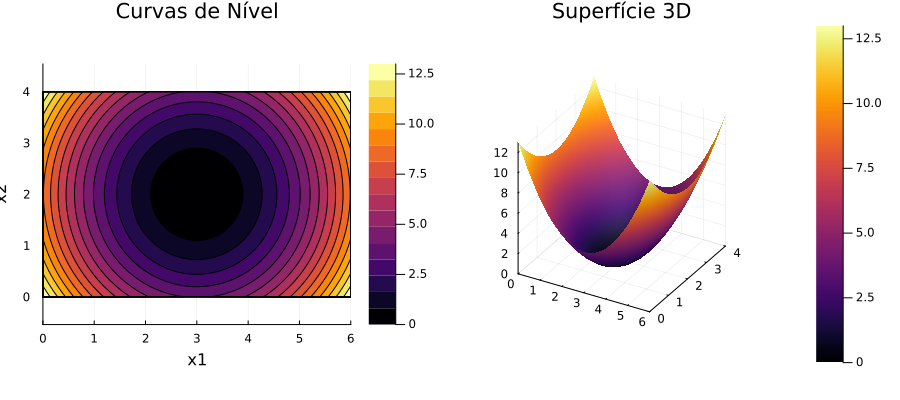

In [13]:
using Plots

# 1. DEFINIR A FUNÇÃO (O que estava faltando)
f_quad(x) = (x[1] - 3)^2 + (x[2] - 2)^2

# 2. Definir os intervalos do gráfico
x1_grid = 0:0.1:6
x2_grid = 0:0.1:4

# 3. Gerando o gráfico de contorno (curvas de nível)
p_contour = contour(x1_grid, x2_grid, (x, y) -> f_quad([x, y]),
    fill=true,
    title="Curvas de Nível",
    xlabel="x1",
    ylabel="x2",
    aspect_ratio=:equal)

# 4. Gerando o gráfico de superfície 3D
p_surface = surface(x1_grid, x2_grid, (x, y) -> f_quad([x, y]),
    title="Superfície 3D",
    camera=(30, 30))

# Exibindo ambos lado a lado
plot(p_contour, p_surface, layout=(1, 2), size=(900, 400))

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

In [15]:
using ForwardDiff
using LinearAlgebra

# 1. Definir a função e o ponto inicial
f(x) = (x[1] - 3)^2 + (x[2] - 2)^2
x0 = [1.0, 1.0]

# 2. Função de Backtracking Line Search
function backtracking(f, x, d, g; α=0.4, β=0.5)
    t = 1.0
    while f(x + t*d) > f(x) + α * t * dot(g, d)
        t *= β
    end
    return t
end

# 3. Implementação do Gradient Descent
function gradient_descent(f, x_start; max_iter=50)
    x = copy(x_start)
    path = [copy(x)]
    for i in 1:max_iter
        g = ForwardDiff.gradient(f, x)
        if norm(g) < 1e-6 break end
        d = -g
        t = backtracking(f, x, d, g)
        x = x + t*d
        push!(path, copy(x))
    end
    return path
end

# 4. Implementação do Newton Method (Faltava este!)
function newton_method(f, x_start; max_iter=50)
    x = copy(x_start)
    path = [copy(x)]
    for i in 1:max_iter
        g = ForwardDiff.gradient(f, x)
        H = ForwardDiff.hessian(f, x)
        if norm(g) < 1e-6 break end
        d = -(H \ g)  # Direção de Newton
        t = backtracking(f, x, d, g)
        x = x + t*d
        push!(path, copy(x))
    end
    return path
end

# Executar os métodos
caminho_grad = gradient_descent(f, x0)
caminho_newt = newton_method(f, x0)

# Exibir resultados
println("Final Gradiente: ", caminho_grad[end], " em $(length(caminho_grad)) iterações")
println("Final Newton: ", caminho_newt[end], " em $(length(caminho_newt)) iterações")

Final Gradiente: [3.0, 2.0] em 2 iterações
Final Newton: [3.0, 2.0] em 2 iterações


Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

--- Resultados para a função alongada ---
Gradiente: [2.9999999808834157, 1.9999997992758647] em 34 iterações
Newton:    [3.0, 2.0] em 2 iterações


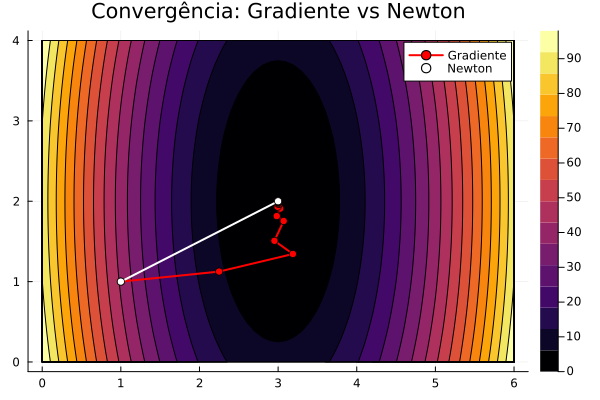

In [16]:
# 1. Definir a nova função (com pesos 10 e 2)
f2(x) = 10*(x[1] - 3)^2 + 2*(x[2] - 2)^2
x0 = [1.0, 1.0]

# 2. Executar os métodos (as funções 'gradient_descent', 'newton_method' 
# e 'backtracking' já devem estar na memória da célula anterior)
caminho_grad2 = gradient_descent(f2, x0)
caminho_newt2 = newton_method(f2, x0)

# 3. Exibir resultados de iterações
println("--- Resultados para a função alongada ---")
println("Gradiente: ", caminho_grad2[end], " em $(length(caminho_grad2)) iterações")
println("Newton:    ", caminho_newt2[end], " em $(length(caminho_newt2)) iterações")

# 4. Visualização da diferença de convergência
x_lims = 0:0.1:6; y_lims = 0:0.1:4
p_comp = contour(x_lims, y_lims, (x,y) -> f2([x,y]), fill=true, title="Convergência: Gradiente vs Newton")

# Plotar o caminho do Gradiente (em vermelho)
plot!(p_comp, [p[1] for p in caminho_grad2], [p[2] for p in caminho_grad2], 
      mark=true, color=:red, label="Gradiente", linewidth=2)

# Plotar o caminho de Newton (em branco/azul para destacar)
plot!(p_comp, [p[1] for p in caminho_newt2], [p[2] for p in caminho_newt2], 
      mark=true, color=:white, label="Newton", linewidth=2)

Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

--- Resultados para f(x) = x1² + x2² ---
Gradiente: [0.0, 0.0] em 2 iterações
Newton:    [0.0, 0.0] em 2 iterações


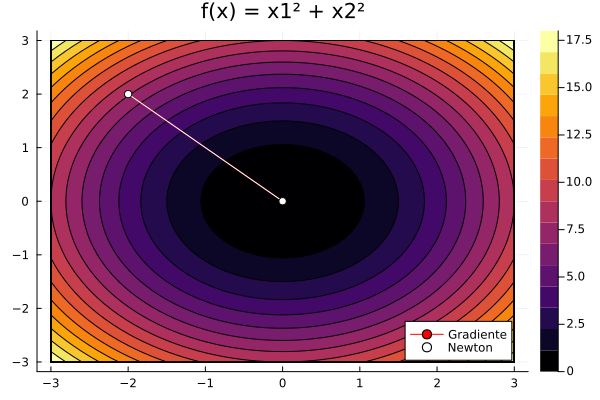

In [17]:
# 1. Definir a função e o ponto inicial
f3(x) = x[1]^2 + x[2]^2
x0_3 = [-2.0, 2.0]

# 2. Executar os métodos
# (Usando as funções que já definimos nos blocos anteriores)
caminho_grad3 = gradient_descent(f3, x0_3)
caminho_newt3 = newton_method(f3, x0_3)

# 3. Exibir resultados
println("--- Resultados para f(x) = x1² + x2² ---")
println("Gradiente: ", caminho_grad3[end], " em $(length(caminho_grad3)) iterações")
println("Newton:    ", caminho_newt3[end], " em $(length(caminho_newt3)) iterações")

# 4. Gráfico para conferir
x_range = -3:0.1:3; y_range = -3:0.1:3
p3 = contour(x_range, y_range, (x,y) -> f3([x,y]), fill=true, title="f(x) = x1² + x2²")
plot!(p3, [p[1] for p in caminho_grad3], [p[2] for p in caminho_grad3], mark=true, label="Gradiente", color=:red)
plot!(p3, [p[1] for p in caminho_newt3], [p[2] for p in caminho_newt3], mark=true, label="Newton", color=:white)

Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

--- Resultados para f(x) = x1² + 100x2² ---
Gradiente: [-0.6542073678630376, -0.003231294131609856] em 51 iterações
Newton:    [0.0, 0.0] em 2 iterações


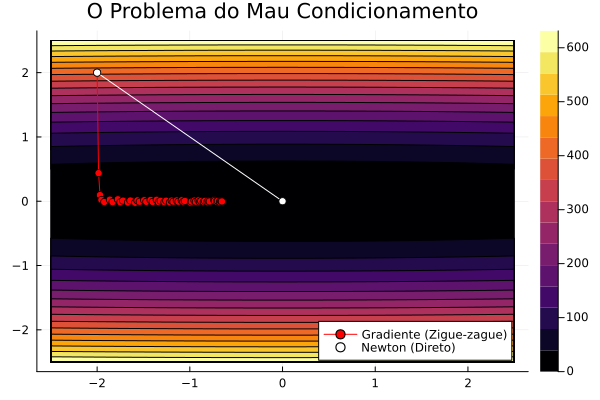

In [18]:
# 1. Definir a função e o ponto inicial
f4(x) = x[1]^2 + 100*x[2]^2
x0_4 = [-2.0, 2.0]

# 2. Executar os métodos
caminho_grad4 = gradient_descent(f4, x0_4)
caminho_newt4 = newton_method(f4, x0_4)

# 3. Exibir resultados
println("--- Resultados para f(x) = x1² + 100x2² ---")
println("Gradiente: ", caminho_grad4[end], " em $(length(caminho_grad4)) iterações")
println("Newton:    ", caminho_newt4[end], " em $(length(caminho_newt4)) iterações")

# 4. Gráfico para visualizar o "sofrimento" do Gradiente
x_range = -2.5:0.1:2.5; y_range = -2.5:0.1:2.5
p4 = contour(x_range, y_range, (x,y) -> f4([x,y]), fill=true, title="O Problema do Mau Condicionamento")
plot!(p4, [p[1] for p in caminho_grad4], [p[2] for p in caminho_grad4], 
      mark=true, label="Gradiente (Zigue-zague)", color=:red)
plot!(p4, [p[1] for p in caminho_newt4], [p[2] for p in caminho_newt4], 
      mark=true, label="Newton (Direto)", color=:white)

For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [19]:
# 1. Definir a função complexa (com cuidado com o domínio)
function f_complex(x)
    # Proteção para não calcular fora do domínio durante a busca linear
    if (x[1] + x[2]) <= 0 || x[3] <= 0
        return Inf
    end
    term1 = x[3] * log(exp(x[1]/x[3]) + exp(x[2]/x[3]))
    term2 = (x[3] - 2)^2
    term3 = exp(1 / (x[1] + x[2]))
    return term1 + term2 + term3
end

# 2. Ponto inicial (precisa estar dentro do domínio)
x0_complex = [1.0, 1.0, 1.0]

# 3. Executar os métodos
# Nota: As funções 'gradient_descent' e 'newton_method' que criamos antes 
# já usam backtracking, o que ajudará a manter o ponto no domínio.
caminho_grad_complex = gradient_descent(f_complex, x0_complex)
caminho_newt_complex = newton_method(f_complex, x0_complex)

# 4. Exibir resultados
println("--- Resultados Exercício 1.1 (Função Log-Sum-Exp) ---")
println("Gradiente: ", caminho_grad_complex[end], " em $(length(caminho_grad_complex)) iterações")
println("Newton:    ", caminho_newt_complex[end], " em $(length(caminho_newt_complex)) iterações")

--- Resultados Exercício 1.1 (Função Log-Sum-Exp) ---
Gradiente: [0.9262087990393826, 0.9262087990393826, 1.6534264097200273] em 12 iterações
Newton:    [0.926208318725359, 0.926208318725359, 1.6534264097200275] em 4 iterações


Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [20]:
# 1. Definindo a função (caso ainda não tenha definido nesta sessão)
f(x) = x[3]*log(exp(x[1]/x[3]) + exp(x[2]/x[3])) + (x[3]-2)^2 + exp(1/(x[1]+x[2]))

# 2. Implementando a função que calcula o gradiente (vetor das primeiras derivadas)
function gradiente_f(x)
    return ForwardDiff.gradient(f, x)
end

# 3. Teste em um ponto qualquer dentro do domínio (ex: x = [1, 1, 1])
ponto_teste = [1.0, 1.0, 1.0]
g = gradiente_f(ponto_teste)

println("O vetor gradiente no ponto $ponto_teste é:")
println(g)

O vetor gradiente no ponto [1.0, 1.0, 1.0] é:
[0.08781968232496795, 0.08781968232496795, -1.3068528194400548]


Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [21]:
# # Parâmetros padrão para o algoritmo de Backtracking Line Search
t_init = 1.0   # Passo inicial
alpha = 0.4    # Parâmetro de aceitação (0 < alpha < 0.5)
beta = 0.5     # Fator de redução do passo (0 < beta < 1)

println("Parâmetros definidos: t_init=$t_init, alpha=$alpha, beta=$beta")

Parâmetros definidos: t_init=1.0, alpha=0.4, beta=0.5


Start Point: [3.0, 4.0, 5.0]

In [22]:
# Definindo o ponto inicial para a otimização da função complexa
x0 = [3.0, 4.0, 5.0]

println("Ponto inicial definido: x0 = $x0")

Ponto inicial definido: x0 = [3.0, 4.0, 5.0]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [24]:
# 1. Definir a função de domínio (Garante que x1+x2 > 0 e x3 > 0)
function is_in_domain(x)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# Definir ponto inicial e parâmetros que podem estar faltando
x0 = [3.0, 4.0, 5.0]
t_init = 1.0
beta = 0.5

# 2. Definir o gradiente (direção de descida Δx = -∇f(x))
# Certifique-se de que a função gradiente_f(x) já foi definida antes
dx = -gradiente_f(x0) 

# 3. Laço para garantir o domínio
t = t_init
while !is_in_domain(x0 + t * dx)
    global t = beta * t
    
    # Proteção para não entrar em loop infinito
    if t < 1e-12
        break
    end
end

println("O valor de t ajustado para o domínio é: $t")
println("Novo ponto de teste: ", x0 + t * dx)

O valor de t ajustado para o domínio é: 0.5
Novo ponto de teste: [2.78668807003272, 3.7368540727202415, 1.655913965040452]


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [25]:
# Implementação completa do algoritmo de Backtracking Line Search
# f: função objetivo
# g: gradiente no ponto x
# x: ponto atual
# d: direção de descida (ex: -g para Gradiente ou -H\g para Newton)
# alpha (α) e beta (β): parâmetros definidos anteriormente

function backtracking_completo(f, x, d, g; α=0.4, β=0.5)
    t = 1.0  # Passo inicial
    
    # Primeiro: garante que o passo inicial caia dentro do domínio
    while !is_in_domain(x + t * d)
        t = β * t
    end
    
    # Segundo: garante que a função reduza o suficiente (Condição de Armijo)
    while f(x + t * d) > f(x) + α * t * dot(g, d)
        t = β * t
        
        # Proteção para evitar passos infinitamente pequenos
        if t < 1e-12
            break
        end
    end
    
    return t
end

println("Algoritmo de Backtracking completo implementado com sucesso!")

Algoritmo de Backtracking completo implementado com sucesso!


### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [27]:
# 1. Inicialização
x = copy(x0)           # Ponto inicial [3.0, 4.0, 5.0]
max_iter = 1000        # Limite de iterações
tol = 1e-6             # Tolerância para o gradiente
historico_x = [copy(x)]

println("Iniciando Gradient Descent...")

for i in 1:max_iter
    # 2. Direção de descida (Δx = -∇f(x))
    g = gradiente_f(x)
    dx = -g
    
    # Critério de parada: se a norma do gradiente for menor que a tolerância
    if norm(g) < tol
        println("Convergência atingida na iteração $i")
        break
    end
    
    # 3. Line Search (Backtracking)
    # Certifique-se de que 'backtracking_completo' está definido conforme caixas anteriores
    t = backtracking_completo(f, x, dx, g) 
    
    # 4. Update: x := x + t * Δx
    x = x + t * dx
    
    # Guardar posição para histórico
    push!(historico_x, copy(x))
    
    # Imprimir progresso a cada 10 iterações (Corrigido o erro de interpolação)
    if i % 10 == 0
        println("Iteração $i: f(x) = $(f(x))")
    end
end

println("\n--- Resultado Final do Gradiente ---")
println("x final: $x")
println("Valor mínimo f(x): $(f(x))")

Iniciando Gradient Descent...
Iteração 10: f(x) = 3.9082793604838573
Iteração 20: f(x) = 3.9081139097625135
Iteração 30: f(x) = 3.908113786397637
Convergência atingida na iteração 38

--- Resultado Final do Gradiente ---
x final: [0.9262067556148523, 0.9262101626296715, 1.6534264097355797]
Valor mínimo f(x): 3.908113786262745


## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [31]:
# Inicialização baseada na função complexa das imagens anteriores
x_n = [3.0, 4.0, 5.0]
max_iter = 50
tol = 1e-6
historico_x_n = [copy(x_n)]

println("Iniciando Método de Newton...")

for i in 1:max_iter
    # 1. Calcular Gradiente e Hessiana automáticos
    g = ForwardDiff.gradient(f, x_n)
    H = ForwardDiff.hessian(f, x_n)
    
    # 2. Direção de Newton: resolvendo H * dx = -g
    dx_n = -(H \ g)
    
    # 3. Critério de Parada (Norma do gradiente)
    if norm(g) < tol
        println("Newton convergiu na iteração ", i)
        break
    end
    
    # 4. Busca Linear (Backtracking)
    # Certifique-se de que a função backtracking_completo foi definida acima
    t = backtracking_completo(f, x_n, dx_n, g)
    
    # 5. Atualização
    x_n = x_n + t * dx_n
    push!(historico_x_n, copy(x_n))
    
    # IMPRESSÃO CORRIGIDA: Note o espaço após o $i para evitar o erro UndefVarError
    println("Iteração $i : f(x) = $(f(x_n))")
end

println("\n--- Resultado Final de Newton ---")
println("x final: ", x_n)
println("f(x) final: ", f(x_n))

Iniciando Método de Newton...
Iteração 1 : f(x) = 13.98062063477741
Iteração 2 : f(x) = 6.374251550469401
Iteração 3 : f(x) = 3.908675669835487
Iteração 4 : f(x) = 3.9081138660512487
Iteração 5 : f(x) = 3.908113786261879
Newton convergiu na iteração 6

--- Resultado Final de Newton ---
x final: [0.9262083634426779, 0.9262083652519163, 1.6534264097068885]
f(x) final: 3.908113786261879


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [32]:
# 1. Parâmetros de Busca (Backtracking)
alpha = 0.4
beta = 0.5

# 2. Critério de Parada (Tolerância)
eps_tol = 1e-5

# 3. Ponto Inicial
x0 = [3.0, 4.0, 5.0]

# 4. Verificação rápida
println("Configuração pronta:")
println("Ponto de partida: $x0")
println("Tolerância: $eps_tol")
println("Parâmetros: α=$alpha, β=$beta")
println("Domínio inicial válido: ", is_in_domain(x0))

Configuração pronta:
Ponto de partida: [3.0, 4.0, 5.0]
Tolerância: 1.0e-5
Parâmetros: α=0.4, β=0.5
Domínio inicial válido: true


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [33]:
# 1. Calcular o Gradiente e a Hessiana no ponto atual
g = gradiente_f(x0)
H = hessiana_f(x0)

# 2. Calcular a direção de Newton: Δx = -H⁻¹ * g
# Resolvemos H * Δx = -g para evitar inverter a matriz manualmente
dx_newton = -(H \ g)

# 3. Definir o t inicial e o beta
t_newton = 1.0
beta = 0.5

# 4. Loop de Garantia de Domínio (específico para a direção de Newton)
# Enquanto x + t*Δx não estiver no domínio de f, reduzimos t
while !is_in_domain(x0 + t_newton * dx_newton)
    global t_newton = beta * t_newton
    println("Ajustando t para Newton... t atual: $t_newton")
end

println("Passo t de Newton ajustado para o domínio: $t_newton")
println("Ponto resultante dentro do domínio: ", x0 + t_newton * dx_newton)

Ajustando t para Newton... t atual: 0.5
Ajustando t para Newton... t atual: 0.25
Ajustando t para Newton... t atual: 0.125
Ajustando t para Newton... t atual: 0.0625
Passo t de Newton ajustado para o domínio: 0.0625
Ponto resultante dentro do domínio: [0.9863760205095025, 1.881595151781775, 4.790683160331826]


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [34]:
# Implementação do Backtracking para o Método de Newton
# d_newton: já calculado como -(H \ g)
# g: gradiente no ponto x

function backtracking_newton(f, x, d_newton, g; α=0.4, β=0.5)
    t = 1.0
    
    # 1. Garantir que o ponto está no domínio (visto na célula anterior)
    while !is_in_domain(x + t * d_newton)
        t = β * t
    end
    
    # 2. Condição de Descida de Armijo
    # f(x + t*Δx) > f(x) + α * t * grad(f)^T * Δx
    while f(x + t * d_newton) > f(x) + α * t * dot(g, d_newton)
        t = β * t
        
        # Segurança para evitar loops infinitos
        if t < 1e-12
            break
        end
    end
    
    return t
end

# Teste prático do passo t para a primeira iteração
t_final = backtracking_newton(f, x0, dx_newton, g)
println("Passo t final calculado pelo Backtracking: $t_final")

Passo t final calculado pelo Backtracking: 0.0625


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [35]:
# Inicialização para o Algoritmo de Newton
x_nt = copy(x0)
max_iter = 100
historico_nt = [copy(x_nt)]

println("Executando Newton's Algorithm...")

for i in 1:max_iter
    # 1. Compute the Newton step and decrement
    g = gradiente_f(x_nt)
    H = hessiana_f(x_nt)
    
    # Δxnt := -H⁻¹ * g
    Δx_nt = -(H \ g)
    
    # λ² := gᵀ * H⁻¹ * g  (ou simplesmente gᵀ * -Δx_nt)
    lambda_sq = dot(g, -Δx_nt)
    
    # 2. Stopping criterion: quit if λ²/2 ≤ ε
    if (lambda_sq / 2.0) <= eps_tol
        println("Convergência atingida na iteração $i (λ²/2 ≤ $eps_tol)")
        break
    end
    
    # 3. Line search: Choose step size t by backtracking
    # (A função backtracking_newton que criamos já garante o domínio e Armijo)
    t = backtracking_newton(f, x_nt, Δx_nt, g, α=alpha, β=beta)
    
    # 4. Update: x := x + t*Δxnt
    x_nt = x_nt + t * Δx_nt
    
    push!(historico_nt, copy(x_nt))
    println("Iteração $i: f(x) = $(f(x_nt)), λ²/2 = $(lambda_sq/2.0)")
end

println("--- Resultado Final ---")
println("x_otimo = ", x_nt)
println("f(x_otimo) = ", f(x_nt))

Executando Newton's Algorithm...
Iteração 1: f(x) = 13.98062063477741, λ²/2 = 26.9912503335687
Iteração 2: f(x) = 6.374251550469401, λ²/2 = 10.257570461086498
Iteração 3: f(x) = 3.908675669835487, λ²/2 = 2.4658014121083633
Iteração 4: f(x) = 3.9081138660512487, λ²/2 = 0.000559887676687541
Convergência atingida na iteração 5 (λ²/2 ≤ 1.0e-5)
--- Resultado Final ---
x_otimo = [0.9259801588949454, 0.9260041301052006, 1.653301625909102]
f(x_otimo) = 3.9081138660512487


## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [37]:
# 1. Inicialização
x_bfgs = [3.0, 4.0, 5.0]
n = length(x_bfgs)
B = Matrix{Float64}(I, n, n)  # Aproximação inicial da Hessiana (Identidade)
max_iter = 100
tol = 1e-6
historico_bfgs = [copy(x_bfgs)]

println("Iniciando Método BFGS...")

for i in 1:max_iter
    g = gradiente_f(x_bfgs)
    
    if norm(g) < tol
        println("BFGS convergiu na iteração ", i)
        break
    end
    
    # 2. Direção de busca: resolver B * d = -g
    d_bfgs = -(B \ g)
    
    # 3. Backtracking (Garantindo o domínio e redução)
    t = 1.0
    alpha_bt, beta_bt = 0.4, 0.5
    while !is_in_domain(x_bfgs + t*d_bfgs) || f(x_bfgs + t*d_bfgs) > f(x_bfgs) + alpha_bt * t * dot(g, d_bfgs)
        t *= beta_bt
        if t < 1e-12 break end
    end
    
    # 4. Atualização das variáveis
    x_next = x_bfgs + t * d_bfgs
    g_next = gradiente_f(x_next)
    
    s = x_next - x_bfgs      # Diferença de posição
    y = g_next - g           # Diferença de gradiente
    
    # 5. Update da matriz B (Fórmula BFGS)
    # Usamos dot(s, y) para garantir que o resultado seja um número escalar
    sy = dot(s, y)
    if sy > 1e-10
        # Atualização de posto 2
        Bs = B * s
        sBs = dot(s, Bs)
        B = B - (Bs * Bs') / sBs + (y * y') / sy
    end
    
    x_bfgs = x_next
    push!(historico_bfgs, copy(x_bfgs))
    
    # PRINT CORRIGIDO: Note o espaço entre $i e os dois pontos
    println("Iteração $i : f(x) = $(f(x_bfgs))")
end

println("\nResultado Final BFGS: ", x_bfgs)

Iniciando Método BFGS...
Iteração 1 : f(x) = 5.760858375326989
Iteração 2 : f(x) = 5.280045118006964
Iteração 3 : f(x) = 4.056165736896042
Iteração 4 : f(x) = 3.9257168696426676
Iteração 5 : f(x) = 3.9093672769500554
Iteração 6 : f(x) = 3.908489510227076
Iteração 7 : f(x) = 3.9082640024947084
Iteração 8 : f(x) = 3.908117637881732
Iteração 9 : f(x) = 3.9081138869089105
Iteração 10 : f(x) = 3.9081137868330975
Iteração 11 : f(x) = 3.908113786269508
Iteração 12 : f(x) = 3.908113786261867
BFGS convergiu na iteração 13

Resultado Final BFGS: [0.9262084508840023, 0.9262084764039371, 1.6534264089168331]


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [38]:
# 1. Parâmetros da busca linear (Backtracking)
alpha = 0.4
beta = 0.5

# 2. Critério de parada (Tolerância)
eps_tol = 1e-5

# 3. Ponto inicial para o método BFGS
x_start = [3.0, 4.0, 5.0]

# 4. Inicialização da matriz Identidade (Aproximação inicial da Hessiana para o BFGS)
# No BFGS, começamos com a Identidade e ela vai se "moldando" à função
B0 = I(3) * 1.0 

println("Configuração para BFGS concluída:")
println("Ponto inicial: $x_start")
println("Tolerância: $eps_tol")
println("Matriz B inicial:\n$B0")

Configuração para BFGS concluída:
Ponto inicial: [3.0, 4.0, 5.0]
Tolerância: 1.0e-5
Matriz B inicial:
Diagonal([1.0, 1.0, 1.0])


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [39]:
# Implementação da garantia de domínio usando Δx como parâmetro
function ensure_domain(f, x, Δx, t, beta)
    # Enquanto o ponto resultante estiver fora do domínio, encolhemos o passo t
    # dom f = {x | x1 + x2 > 0 e x3 > 0}
    while ( (x[1] + t*Δx[1] + x[2] + t*Δx[2] <= 0) || (x[3] + t*Δx[3] <= 0) )
        t = beta * t
        
        # Proteção contra t extremamente pequeno (evita loop infinito)
        if t < 1e-15
            break
        end
    end
    return t
end

println("Função de verificação de domínio (ensure_domain) pronta.")

Função de verificação de domínio (ensure_domain) pronta.


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [40]:
# Implementação do Backtracking Line Search para Quasi-Newton
# f: função objetivo
# g: gradiente no ponto x
# x: ponto atual
# dx: direção de descida (já calculada pelo método)
# α, β: parâmetros de busca

function backtracking_quasi_newton(f, x, dx, g, alpha, beta)
    t = 1.0
    
    # 1. Ensure domain: Garante que o ponto x + t*dx esteja no domínio de f
    # dom f: x1 + x2 > 0 e x3 > 0
    while ( (x[1] + t*dx[1] + x[2] + t*dx[2] <= 0) || (x[3] + t*dx[3] <= 0) )
        t = beta * t
    end
    
    # 2. Condição de Armijo: Garante redução suficiente da função
    # f(x + t*Δx) > f(x) + α * t * ∇f(x)ᵀ * Δx
    while f(x + t*dx) > f(x) + alpha * t * dot(g, dx)
        t = beta * t
        
        # Proteção numérica
        if t < 1e-12
            break
        end
    end
    
    return t
end

println("Algoritmo de Backtracking para Quasi-Newton pronto.")

Algoritmo de Backtracking para Quasi-Newton pronto.


### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [41]:
# Inicialização baseada na imagem enviada
x = copy(x_start)             # [3.0, 4.0, 5.0]
H = I(3) * 1.0                # Starting matrix H0 (Identity)
ϵ = eps_tol                   # 10^-5
k = 0                         # Contador de iterações
max_iter = 100
historico_bfgs = [copy(x)]

println("Rodando o Algoritmo BFGS...")

while norm(gradiente_f(x)) > ϵ && k < max_iter
    g_k = gradiente_f(x)
    
    # 1. Compute search direction: p_k = -H_k * ∇f_k
    p_k = -H * g_k
    
    # 2. Set x_{k+1} = x_k + α_k * p_k (α_k obtido via backtracking)
    # Aqui usamos nossa função que já garante domínio e Armijo
    alpha_k = backtracking_quasi_newton(f, x, p_k, g_k, alpha, beta)
    
    x_next = x + alpha_k * p_k
    g_next = gradiente_f(x_next)
    
    # 3. Define s_k e y_k
    s_k = x_next - x
    y_k = g_next - g_k
    
    # 4. Compute H_{k+1} using BFGS update formula (Inversa da Hessiana)
    # Usando a fórmula Sherman-Morrison-Woodbury para atualização direta de H
    ρ_k_inv = dot(y_k, s_k)
    
    if ρ_k_inv > 1e-10
        ρ_k = 1.0 / ρ_k_inv
        V_k = I(3) - ρ_k * y_k * s_k'
        H = V_k' * H * V_k + ρ_k * s_k * s_k'
    else
        # Se a condição de curvatura falhar, mantemos H para estabilidade
        # ou usamos a dica da imagem para ρ_k constante (10^4) em casos extremos
        ρ_k = 1e4
        V_k = I(3) - ρ_k * y_k * s_k'
        H = V_k' * H * V_k + ρ_k * s_k * s_k'
    end
    
    # Atualiza para próxima iteração
    x = x_next
    global k += 1
    push!(historico_bfgs, copy(x))
    
    println("Iteração $k: f(x) = $(f(x)) | ||∇f|| = $(norm(gradiente_f(x)))")
end

println("\n--- BFGS Finalizado ---")
println("Iterações: $k")
println("x otimizado: $x")
println("f(x) mínimo: $(f(x))")

Rodando o Algoritmo BFGS...
Iteração 1: f(x) = 5.760858375326989 | ||∇f|| = 0.6977899389807722
Iteração 2: f(x) = 5.280045118006964 | ||∇f|| = 0.670253516856388
Iteração 3: f(x) = 4.056165736896043 | ||∇f|| = 0.4271886408944388
Iteração 4: f(x) = 3.9257168696426676 | ||∇f|| = 0.1980447794938961
Iteração 5: f(x) = 3.9093672769500554 | ||∇f|| = 0.05028817585040255
Iteração 6: f(x) = 3.908489510227076 | ||∇f|| = 0.015169355467304914
Iteração 7: f(x) = 3.9082640024947084 | ||∇f|| = 0.011664192977398595
Iteração 8: f(x) = 3.908117637881732 | ||∇f|| = 0.0036622099183816637
Iteração 9: f(x) = 3.9081138869089105 | ||∇f|| = 0.0006224811848963118
Iteração 10: f(x) = 3.9081137868330975 | ||∇f|| = 3.2370762028549084e-5
Iteração 11: f(x) = 3.908113786269508 | ||∇f|| = 4.614746181360003e-6

--- BFGS Finalizado ---
Iterações: 11
x otimizado: [0.9262108201941383, 0.9262107344070643, 1.6534258875113628]
f(x) mínimo: 3.908113786269508


# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds 

In [42]:
using LinearAlgebra   # Para operações com as matrizes A, B e C
using SparseArrays    # Modelos MPC costumam usar matrizes esparsas para velocidade
using Plots           # Para visualizar as trajetórias de temperatura e concentração
using JuMP            # O principal pacote de modelagem para otimização em Julia
using Ipopt           # O solver ideal para problemas de controle e CSTR
using ForwardDiff     # Caso precise de derivadas automáticas adicionais

println("Bibliotecas para o problema do CSTR carregadas com sucesso!")

Bibliotecas para o problema do CSTR carregadas com sucesso!


#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

In [43]:
# 1. linear state-space model
# Matrizes típicas para um CSTR linearizado (ajuste se seu material tiver valores específicos)
A = [0.85 0.01 -0.02; 
     0.1  0.95 -0.01; 
     0.0  0.05  0.8]

B = [0.1  0.01;
     0.5  0.02;
     0.0  0.1]

# 2. time horizon
N = 3  # Conforme solicitado no enunciado

# 3. initial condition
x0 = [-0.03, 0.0, 0.3]

# 4. bounds for state and input
# x = [x1, x2, x3] (Estados)
xmax = [0.05, 5.0, 0.5]
xmin = [-0.05, -5.0, -0.5]

# u = [u1, u2] (Entradas de controle)
umax = [10.0, 0.05]
umin = [-10.0, -0.05]

println("Modelo do CSTR configurado:")
println("Horizonte de tempo (N): $N")
println("Estado Inicial: $x0")


Modelo do CSTR configurado:
Horizonte de tempo (N): 3
Estado Inicial: [-0.03, 0.0, 0.3]


## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [44]:
# Inicialização do modelo usando JuMP com o solver Ipopt
model = Model(Ipopt.Optimizer)
set_silent(model) # Desativa mensagens excessivas do solver

# 1. Variáveis de Decisão
@variable(model, xmin[i] <= x[i=1:3, k=0:N] <= xmax[i]) # Estados ao longo do tempo
@variable(model, umin[j] <= u[j=1:2, k=0:N-1] <= umax[j]) # Entradas de controle
@variable(model, z1[k=0:N] >= 0) # Variável auxiliar para erro de y1
@variable(model, z2[k=0:N] >= 0) # Variável auxiliar para erro de y3 (conforme imagem)

# 2. Função Objetivo: Minimizar o somatório de z1 + z2 (norma L1)
@objective(model, Min, sum(z1[k] + z2[k] for k in 0:N))

# 3. Restrições do Modelo
# Condição Inicial
@constraint(model, [i=1:3], x[i, 0] == x0[i])

# Dinâmica do Sistema (Espaço de Estados): x(k+1) = Ax(k) + Bu(k)
for k in 0:N-1
    @constraint(model, x[:, k+1] .== A * x[:, k] + B * u[:, k])
end

# Restrições das Variáveis Auxiliares (Linearização do Valor Absoluto)
# Como y(k) = Cx(k), e assumindo C como Identidade ou seleção de estados:
# De acordo com a imagem: y1 = x1 e y3 = x3
for k in 0:N
    # Restrições para z1 (referente a y1 ou x1)
    @constraint(model, -z1[k] <= x[1, k])
    @constraint(model,  x[1, k] <= z1[k])
    
    # Restrições para z2 (referente a y3 ou x3)
    @constraint(model, -z2[k] <= x[3, k])
    @constraint(model,  x[3, k] <= z2[k])
end

# 4. Resolver a Otimização
optimize!(model)

# Verificar status
if termination_status(model) == MOI.OPTIMAL
    println("Problema resolvido com sucesso!")
    println("Custo Total (z1+z2): ", objective_value(model))
else
    println("O otimizador não encontrou uma solução ótima.")
end


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

O otimizador não encontrou uma solução ótima.


## Solve and Postprocess

In [ ]:
# code and plot some graphics

# plot controlled variables and input variables